<a href="https://www.kaggle.com/code/mobeenfatimah/amazon-ml-challenge-2026-entity-resolution?scriptVersionId=352724220" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="
    background-image: linear-gradient(rgba(15, 23, 42, 0.85), rgba(15, 23, 42, 0.85)), url('https://images.unsplash.com/photo-1518770660439-4636190af475?auto=format&fit=crop&w=1200&q=80');
    background-size: cover;
    background-position: center;
    padding: 32px;
    border-radius: 12px;
    color: #F8FAFC;
    font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif;
    box-shadow: 0 10px 25px -5px rgba(0, 0, 0, 0.3);
">
    <h1 style="color: #FFFFFF; border-bottom: 2px solid #38BDF8; padding-bottom: 12px; margin-top: 0; font-size: 2.2em; font-weight: 700;">
        Amazon ML Challenge 2026 — Business Entity Resolution
    </h1>
    <p style="font-size: 1.1em; line-height: 1.6; color: #E2E8F0; margin-bottom: 24px;">
        A fast, interactive end-to-end pipeline for the Amazon ML Challenge 2026 dataset. This notebook treats the task as a <strong>large-scale entity-resolution problem</strong>: each Source 1 business must be linked to <strong>zero, one, or many</strong> corresponding records in Source 2 and Source 3.
    </p>
    <details style="background: rgba(255, 255, 255, 0.08); border: 1px solid rgba(255, 255, 255, 0.15); padding: 16px; border-radius: 8px; cursor: pointer; transition: all 0.3s ease;">
        <summary style="font-size: 1.15em; font-weight: 600; color: #38BDF8; outline: none;">
            Click to expand/collapse pipeline workflow
        </summary>
        <ul style="margin-top: 16px; margin-bottom: 8px; line-height: 1.8; color: #F1F5F9; padding-left: 20px;">
            <li>Fast dataset discovery and schema inspection</li>
            <li>Interactive EDA without loading unnecessary columns</li>
            <li>Robust text normalization for names and addresses</li>
            <li>Country-aware blocking that keeps the pipeline open-set</li>
            <li>Exact and high-confidence candidate generation</li>
            <li>Precision-oriented matching designed around <strong>F0.5</strong></li>
            <li>A lightweight validation framework using the training ground truth</li>
            <li>Test-set inference</li>
            <li><code>matching_results.tsv</code> and <code>candidate_pairs.tsv</code> output generation</li>
            <li>Submission-format validation</li>
        </ul>
    </details>
    <div style="margin-top: 24px; padding: 16px; background: rgba(56, 189, 248, 0.1); border-left: 4px solid #38BDF8; border-radius: 4px;">
        <strong style="color: #38BDF8;">Design Principle:</strong> 
        The dataset is very large, so this notebook deliberately avoids expensive all-pairs fuzzy matching. Instead, it uses <strong>blocking + deterministic/high-confidence matching</strong>, which is significantly faster and easier to audit.
    </div>

## 1.Environment setup

In [1]:
# ============================================================
# 1. SETUP — FAST, LIGHTWEIGHT, KAGGLE-FRIENDLY
# ============================================================
import os
import re
import gc
import time
import math
import warnings
from pathlib import Path
from collections import defaultdict, Counter

import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

# Optional high-performance dataframe engine.
try:
    import polars as pl
    HAS_POLARS = True
except Exception:
    HAS_POLARS = False

# Fast string similarity library. Kaggle commonly has it installed.
try:
    from rapidfuzz import fuzz
    HAS_RAPIDFUZZ = True
except Exception:
    HAS_RAPIDFUZZ = False

print("Environment ready")
print("Polars:", HAS_POLARS)
print("RapidFuzz:", HAS_RAPIDFUZZ)

Environment ready
Polars: True
RapidFuzz: False


## 2. Locate the dataset automatically

Kaggle mounts datasets under `/kaggle/input/<dataset-slug>/`.

We will **search rather than hard-code a single versioned path**, so the notebook remains reusable if the dataset version changes.

The official challenge format uses TSV files. In particular, the ground-truth file contains a Source 1 ID and a comma-separated list of matching Source 2/3 IDs.

In [2]:
import os
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")

# Print all available datasets in /kaggle/input
print("Available datasets in /kaggle/input:")
for item in INPUT_ROOT.iterdir():
    print(" -", item.name)

# Attempt fuzzy match for Amazon datasets or grab the first directory available
dataset_dirs = [p for p in INPUT_ROOT.iterdir() if p.is_dir()]

# Try to find a directory containing 'amazon' or fallback to the first attached dataset
DATA_ROOT = next((p for p in dataset_dirs if "amazon" in p.name.lower()), None)

if DATA_ROOT is None and dataset_dirs:
    DATA_ROOT = dataset_dirs[0]

if DATA_ROOT is None:
    raise FileNotFoundError(
        "No datasets found in /kaggle/input. Ensure you have added the dataset in the right-side panel."
    )

print("\nSelected DATA_ROOT:", DATA_ROOT)

# List all files inside the directory
all_files = sorted(DATA_ROOT.rglob("*"))
for f in all_files:
    if f.is_file():
        print(" -", f.relative_to(DATA_ROOT))

Available datasets in /kaggle/input:
 - datasets

Selected DATA_ROOT: /kaggle/input/datasets
 - satwiksps/amazon-ml-challenge-2026/dataset/test/test_source1.tsv
 - satwiksps/amazon-ml-challenge-2026/dataset/test/test_source2.tsv
 - satwiksps/amazon-ml-challenge-2026/dataset/test/test_source3.tsv
 - satwiksps/amazon-ml-challenge-2026/dataset/train/train_ground_truth.tsv
 - satwiksps/amazon-ml-challenge-2026/dataset/train/train_source1.tsv
 - satwiksps/amazon-ml-challenge-2026/dataset/train/train_source2.tsv
 - satwiksps/amazon-ml-challenge-2026/dataset/train/train_source3.tsv
 - satwiksps/amazon-ml-challenge-2026/validate_submission.py


## 3. Confirm the challenge file structure

A crucial detail is that these are **tab-separated files**. Reading them as comma-separated CSVs can collapse the entire row into one column.

In [3]:
# ============================================================
# 3. RESOLVE TRAIN / TEST PATHS
# ============================================================
def find_file(filename):
    hits = list(DATA_ROOT.rglob(filename))
    if not hits:
        raise FileNotFoundError(f"Could not find {filename}")
    return hits[0]

FILES = {
    "train_s1": find_file("train_source1.tsv"),
    "train_s2": find_file("train_source2.tsv"),
    "train_s3": find_file("train_source3.tsv"),
    "ground_truth": find_file("train_ground_truth.tsv"),
    "test_s1": find_file("test_source1.tsv"),
    "test_s2": find_file("test_source2.tsv"),
    "test_s3": find_file("test_source3.tsv"),
}

for k, v in FILES.items():
    print(f"{k:14s} -> {v}")

train_s1       -> /kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/dataset/train/train_source1.tsv
train_s2       -> /kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/dataset/train/train_source2.tsv
train_s3       -> /kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/dataset/train/train_source3.tsv
ground_truth   -> /kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/dataset/train/train_ground_truth.tsv
test_s1        -> /kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/dataset/test/test_source1.tsv
test_s2        -> /kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/dataset/test/test_source2.tsv
test_s3        -> /kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/dataset/test/test_source3.tsv


## 4. Dataset size — measure first, optimize second

This challenge is genuinely large. A published dataset card reports roughly **26.4 million records across train and test**, so a conventional pandas `read_csv()` of every file is not the best default. citeturn0search2

We therefore use:

- **Polars** when available
- column projection
- small previews for EDA
- sampling for expensive diagnostics
- vectorized normalization
- blocking instead of Cartesian joins

In [4]:
# ============================================================
# 4. FILE SIZES + SMALL PREVIEWS
# ============================================================
for k, path in FILES.items():
    size_mb = path.stat().st_size / (1024**2)
    print(f"{k:14s} {size_mb:10.1f} MB")

def preview_tsv(path, n=5):
    return pd.read_csv(path, sep="\t", nrows=n)

print("\nTRAIN SOURCE 1 PREVIEW")
display(preview_tsv(FILES["train_s1"]))

print("\nGROUND TRUTH PREVIEW")
display(preview_tsv(FILES["ground_truth"]))

train_s1            200.3 MB
train_s2            466.6 MB
train_s3            480.4 MB
ground_truth        121.1 MB
test_s1             166.9 MB
test_s2             485.9 MB
test_s3             482.6 MB

TRAIN SOURCE 1 PREVIEW


,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India



GROUND TRUTH PREVIEW


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."


## 5. Load only what we need

For this challenge, the core fields are:

- `entity_id`
- `business_name`
- `business_address`
- `country`

The ground truth contains:

- `source1_entity_id`
- `matched_entity_ids`

Keeping the schema narrow reduces memory pressure and makes subsequent operations faster.

In [5]:
# ============================================================
# 5. SCHEMA CHECK
# ============================================================
CORE_COLS = ["entity_id", "business_name", "business_address", "country"]

for name in ["train_s1", "train_s2", "train_s3", "test_s1", "test_s2", "test_s3"]:
    df = pd.read_csv(FILES[name], sep="\t", nrows=3)
    print(f"\n{name}")
    print(df.dtypes)
    print("columns:", list(df.columns))


train_s1
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address', 'country']

train_s2
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address', 'country']

train_s3
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address', 'country']

test_s1
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address', 'country']

test_s2
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address'

## 6. Fast exploratory sample

Full-scale EDA on tens of millions of rows is usually unnecessary.

Instead, we take a reproducible sample from each source and inspect:

- missingness
- country distribution
- text lengths
- duplicate normalized values
- example noise patterns

This gives us useful structural information without turning EDA into the slowest part of the notebook.

In [6]:
# ============================================================
# 6. SAMPLE-BASED EDA
# ============================================================
SAMPLE_N = 50_000
RANDOM_STATE = 42

def sample_tsv(path, n=SAMPLE_N, seed=RANDOM_STATE):
    return pd.read_csv(
        path,
        sep="\t",
        usecols=CORE_COLS,
        nrows=n
    )

eda_s1 = sample_tsv(FILES["train_s1"])
eda_s2 = sample_tsv(FILES["train_s2"])
eda_s3 = sample_tsv(FILES["train_s3"])

for label, df in [("S1", eda_s1), ("S2", eda_s2), ("S3", eda_s3)]:
    print(f"\n===== {label} =====")
    print("rows:", len(df))
    print("missing:")
    display(df.isna().mean().mul(100).round(2).to_frame("missing_%"))
    print("countries:")
    display(df["country"].value_counts(dropna=False).head(15).to_frame("count"))


===== S1 =====
rows: 50000
missing:


,missing_%
entity_id,0.0
business_name,0.0
business_address,0.0
country,0.0


countries:


,count
country,
US,29965
India,20035



===== S2 =====
rows: 50000
missing:


...

,count
country,
US,30097
India,19903



===== S3 =====
rows: 50000
missing:


,missing_%
entity_id,0.00
business_name,0.00
business_address,3.48
country,0.00


countries:


,count
country,
US,29790
India,20210


## 7. Visualize the sample

The following compact dashboard gives us a quick feel for the data.

Because the challenge is entity resolution rather than classical classification, the most useful first plots are:

1. records by country
2. business-name length
3. address length
4. missing-value rates

These are sampled visualizations, not estimates intended to replace the full dataset statistics.

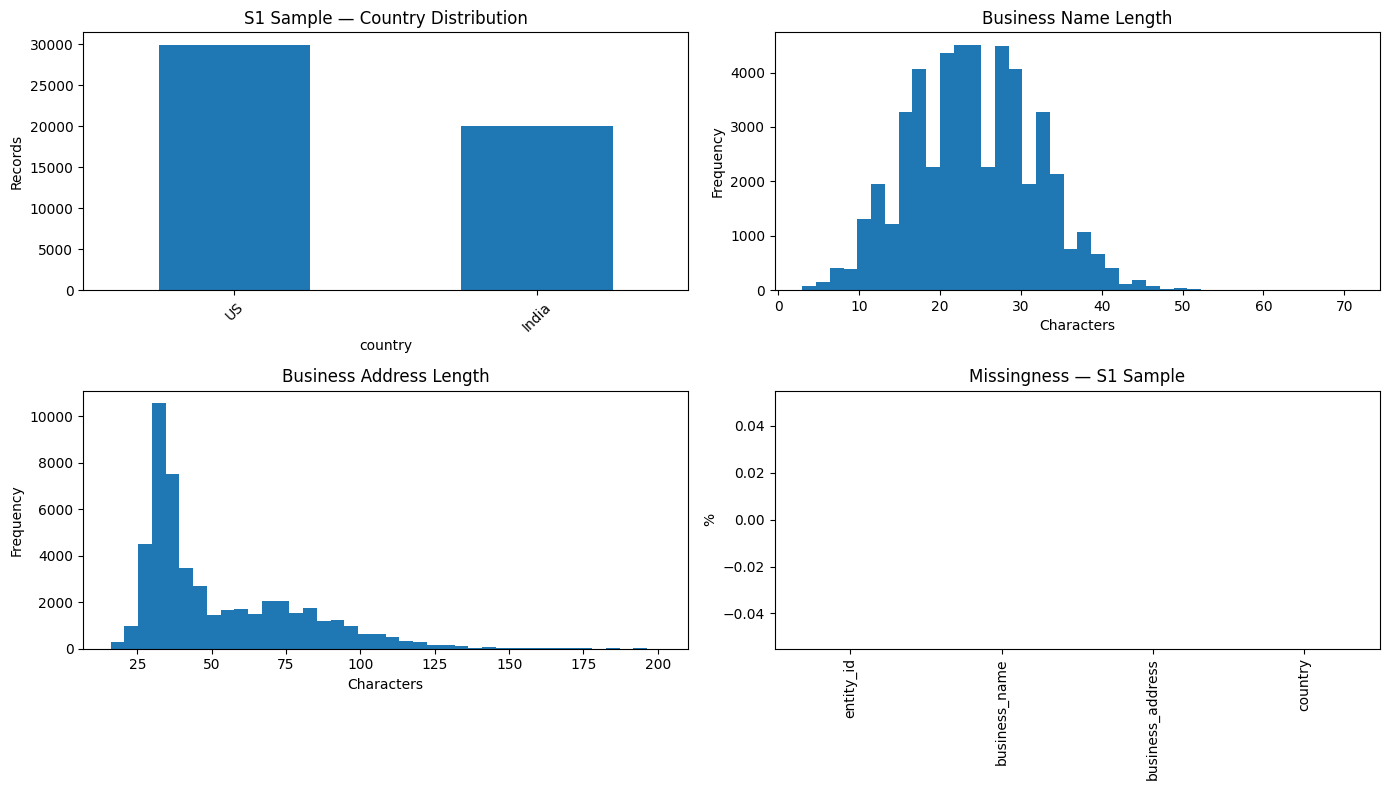

In [7]:
# ============================================================
# 7. QUICK VISUAL DASHBOARD
# ============================================================
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 8))

ax1 = fig.add_subplot(2, 2, 1)
eda_s1["country"].value_counts().head(10).plot(kind="bar", ax=ax1)
ax1.set_title("S1 Sample — Country Distribution")
ax1.set_ylabel("Records")
ax1.tick_params(axis="x", rotation=45)

ax2 = fig.add_subplot(2, 2, 2)
eda_s1["business_name"].fillna("").str.len().clip(upper=100).plot(kind="hist", bins=40, ax=ax2)
ax2.set_title("Business Name Length")
ax2.set_xlabel("Characters")

ax3 = fig.add_subplot(2, 2, 3)
eda_s1["business_address"].fillna("").str.len().clip(upper=250).plot(kind="hist", bins=40, ax=ax3)
ax3.set_title("Business Address Length")
ax3.set_xlabel("Characters")

ax4 = fig.add_subplot(2, 2, 4)
miss = eda_s1.isna().mean().mul(100)
miss.plot(kind="bar", ax=ax4)
ax4.set_title("Missingness — S1 Sample")
ax4.set_ylabel("%")

plt.tight_layout()
plt.show()

## 8. Build robust text normalization

Business names and addresses can differ because of:

- punctuation
- case
- legal suffixes
- `&` versus `and`
- abbreviations
- whitespace
- Unicode variations
- transliteration/noisy formatting

We therefore maintain **multiple representations** instead of destroying information with one aggressive normalization step.

### Representations

- `norm_name`: conservative normalized name
- `compact_name`: whitespace-free normalized name
- `norm_address`: normalized address
- `compact_address`: compact address
- token signatures for blocking

This is especially useful because a single blocking key can create false negatives.

In [8]:
# ============================================================
# 8. NORMALIZATION FUNCTIONS
# ============================================================
LEGAL_SUFFIXES = {
    "incorporated", "inc", "corporation", "corp",
    "limited", "ltd", "llc", "llp",
    "private", "pvt", "company", "co",
    "limitedliabilitycompany"
}

def normalize_text(x):
    if pd.isna(x):
        return ""
    x = str(x).lower()
    x = x.replace("&", " and ")
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def normalize_name(x):
    s = normalize_text(x)
    tokens = [t for t in s.split() if t not in LEGAL_SUFFIXES]
    return " ".join(tokens)

def normalize_address(x):
    return normalize_text(x)

def compact(s):
    return re.sub(r"\s+", "", s)

def token_signature(s):
    return " ".join(sorted(set(s.split())))

for df in [eda_s1]:
    df["norm_name"] = df["business_name"].map(normalize_name)
    df["norm_address"] = df["business_address"].map(normalize_address)
    df["compact_name"] = df["norm_name"].map(compact)
    df["compact_address"] = df["norm_address"].map(compact)

display(
    eda_s1[
        ["business_name", "norm_name", "business_address", "norm_address"]
    ].head(15)
)

,business_name,norm_name,business_address,norm_address
0,Orelee's Barbershop,orelee s barbershop,"1795 Westchester Drive, High Point, NC",1795 westchester drive high point nc
1,Prime Money,prime money,"17560 Ellis Road, Tahlequah, OK",17560 ellis road tahlequah ok
2,B+ Retail Inc,b retail,"1712 Montebello Avenue, Phoenix, AZ",1712 montebello avenue phoenix az
3,Christ Chapel,christ chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",2100 cameron drive unit apartment g dundalk md
4,Prabhav Business Center,prabhav business center,"797, Lake Town Block A, Kolkata, Howrah, West ...",797 lake town block a kolkata howrah west bengal
5,Custom Wealth Services LLC,custom wealth services,"OH, Columbus, 5559 Orville Avenue",oh columbus 5559 orville avenue
6,Consulting Nyasa Nursing Private Limited,consulting nyasa nursing,"2505, Tower 1, Oakwood, Runwal Greens, Mulund ...",2505 tower 1 oakwood runwal greens mulund gore...
7,Nexus Anchor Rain,nexus anchor rain,"1111 Church Street, Unit 2007, Nashville, TN",1111 church street unit 2007 nashville tn
8,Moore Bitwise Inc,moore bitwise,"337 Oakland Avenue, Michigan City, IN",337 oakland avenue michigan city in
9,Dermatology Green Medicine,dermatology green medicine,"294 Meadowcreek Drive, Unit Unit 2, Village Of...",294 meadowcreek drive unit unit 2 village of p...


## 9. Inspect normalization quality

Normalization should simplify harmless formatting differences without erasing useful identity information.

The table below lets us visually inspect transformations before using them for matching.

If a normalization rule looks too aggressive for your data, modify it here — the rest of the notebook will automatically use the updated functions.

In [9]:
# ============================================================
# 9. NORMALIZATION INSPECTION
# ============================================================
inspection = eda_s1[
    ["business_name", "norm_name", "business_address", "norm_address", "country"]
].copy()

display(inspection.sample(min(25, len(inspection)), random_state=42))

,business_name,norm_name,business_address,norm_address,country
33553,India Devansh Freight Private Limited,india devansh freight,"No.8, 15Th Cross, Davis Road, Near St.Alphonsu...",no 8 15th cross davis road near st alphonsus h...,India
9427,"Gwynne Simpson, DO",gwynne simpson do,"1954 Kresge Drive, Amherst, OH",1954 kresge drive amherst oh,US
199,Kylie's Hair Studio,kylie s hair studio,"15083 County Road 1400, Apache, OK",15083 county road 1400 apache ok,US
12447,4627 Mountain View Street Associates LLC,4627 mountain view street associates,"415 Lower Pigeon Road, Ashcamp, KY",415 lower pigeon road ashcamp ky,US
39489,Grey Montreal PC,grey montreal pc,"Wythe County, 640 Murphyville Road, VA",wythe county 640 murphyville road va,US
42724,Ewing Rocky Launchpad Corp,ewing rocky launchpad,"1654 Desert Oasis Court, Benson, AZ",1654 desert oasis court benson az,US
10822,Tech Marketing Private Limited,tech marketing,"570/472, Virat Nagar, Lucknow, Uttar Pradesh",570 472 virat nagar lucknow uttar pradesh,India
49498,Highland Institute II,highland institute ii,"218 Gold Finch Drive, IA, Corydon",218 gold finch drive ia corydon,US
4144,Complete Arts LLC,complete arts,"3750 Brockport Spencerport Road, Ogden, NY",3750 brockport spencerport road ogden ny,US
36958,Quality Medical Brands LLC,quality medical brands,"Sioux Falls, 1701 Berkshire Boulevard, SD",sioux falls 1701 berkshire boulevard sd,US


## 10. Understand the matching structure

The Source 1 table is the reference side. Source 2 and Source 3 contain noisy records that may correspond to Source 1.

The important consequence is:

> We do **not** need to compare S1 against S1.

We only need candidate links:

```text
S1 → S2
S1 → S3
```

Country is a powerful first-level partition. The published dataset analysis reports that the provided ground truth contains no cross-country matches, while also warning that **France appears in test but not training**. Therefore, we use country as a blocking field but never hard-code the allowed countries.

In [10]:
# ============================================================
# 10. GROUND-TRUTH SUMMARY
# ============================================================
gt = pd.read_csv(FILES["ground_truth"], sep="\t", dtype=str).fillna("")

def split_ids(x):
    if not x:
        return []
    return [v.strip() for v in x.split(",") if v.strip()]

gt["match_list"] = gt["matched_entity_ids"].map(split_ids)
gt["n_matches"] = gt["match_list"].str.len()

print("Ground-truth rows:", len(gt))
print("Singleton / no-match S1:", int((gt["n_matches"] == 0).sum()))
print("S1 with >=1 match:", int((gt["n_matches"] > 0).sum()))
print("Maximum matches for one S1:", int(gt["n_matches"].max()))

display(gt["n_matches"].describe().to_frame("match_count"))

Ground-truth rows: 2206821
Singleton / no-match S1: 123247
S1 with >=1 match: 2083574
Maximum matches for one S1: 11


,match_count
count,2.206821e+06
mean,3.461253e+00
std,1.705323e+00
min,0.000000e+00
25%,2.000000e+00
50%,3.000000e+00
75%,5.000000e+00
max,1.100000e+01


## 11. Learn the match-count distribution

The challenge is not strictly one-to-one.

A Source 1 entity can have:

- no matches
- one match
- several matches

Therefore, a correct pipeline must **not** simply choose the single highest-scoring candidate.

We will score candidates independently and then produce a list for every S1 entity.

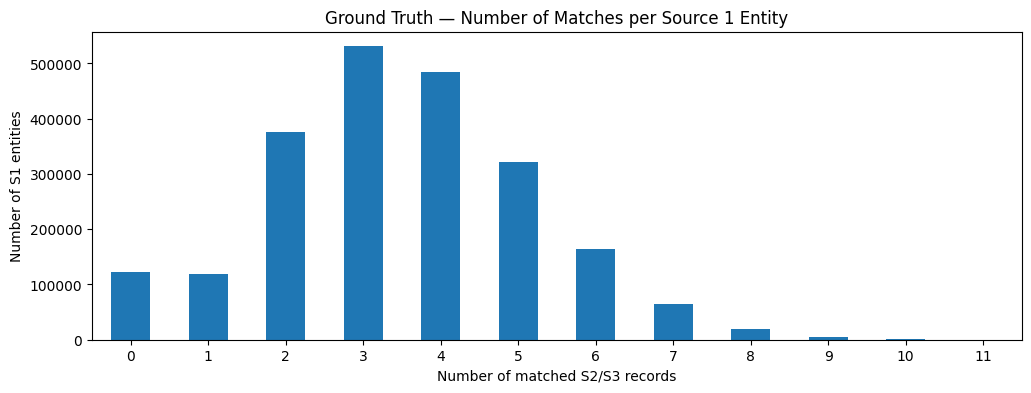

In [11]:
# ============================================================
# 11. MATCH COUNT VISUALIZATION
# ============================================================
counts = gt["n_matches"].value_counts().sort_index()

ax = counts.head(20).plot(kind="bar", figsize=(12, 4))
ax.set_title("Ground Truth — Number of Matches per Source 1 Entity")
ax.set_xlabel("Number of matched S2/S3 records")
ax.set_ylabel("Number of S1 entities")
plt.xticks(rotation=0)
plt.show()

## 12. Exact-match baseline

Before adding fuzzy logic, establish a strong and interpretable baseline.

We test several exact signals:

1. normalized name
2. normalized address
3. normalized name + address
4. compact name + compact address

Exact agreement is particularly valuable in a precision-heavy metric because accidental false merges are expensive.

The official evaluation uses macro-averaged **F₀.₅**, which gives more weight to precision than recall.

In [12]:
# ============================================================
# 12. EXACT MATCH HELPERS
# ============================================================
def prepare_small(df):
    out = df[CORE_COLS].copy()
    out = out.fillna("")
    out["norm_name"] = out["business_name"].map(normalize_name)
    out["norm_address"] = out["business_address"].map(normalize_address)
    out["compact_name"] = out["norm_name"].map(compact)
    out["compact_address"] = out["norm_address"].map(compact)
    out["name_addr_key"] = (
        out["country"].astype(str) + "|" +
        out["compact_name"] + "|" +
        out["compact_address"]
    )
    return out

small_s1 = prepare_small(pd.read_csv(FILES["train_s1"], sep="\t", nrows=20_000, dtype=str))
small_s2 = prepare_small(pd.read_csv(FILES["train_s2"], sep="\t", nrows=50_000, dtype=str))
small_s3 = prepare_small(pd.read_csv(FILES["train_s3"], sep="\t", nrows=50_000, dtype=str))

display(small_s1.head())

,entity_id,business_name,business_address,country,norm_name,norm_address,compact_name,compact_address,name_addr_key
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US,orelee s barbershop,1795 westchester drive high point nc,oreleesbarbershop,1795westchesterdrivehighpointnc,US|oreleesbarbershop|1795westchesterdrivehighp...
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US,prime money,17560 ellis road tahlequah ok,primemoney,17560ellisroadtahlequahok,US|primemoney|17560ellisroadtahlequahok
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US,b retail,1712 montebello avenue phoenix az,bretail,1712montebelloavenuephoenixaz,US|bretail|1712montebelloavenuephoenixaz
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US,christ chapel,2100 cameron drive unit apartment g dundalk md,christchapel,2100camerondriveunitapartmentgdundalkmd,US|christchapel|2100camerondriveunitapartmentg...
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India,prabhav business center,797 lake town block a kolkata howrah west bengal,prabhavbusinesscenter,797laketownblockakolkatahowrahwestbengal,India|prabhavbusinesscenter|797laketownblockak...


## 13. Blocking strategy

A naive comparison would have approximately:

```text
|S1| × (|S2| + |S3|)
```

candidate pairs — far too many.

Instead we generate candidates through several cheap indexes:

### Block A — exact normalized name
`country + compact_name`

### Block B — exact normalized address
`country + compact_address`

### Block C — exact name + address
`country + compact_name + compact_address`

### Block D — token-prefix key
A compact prefix of the strongest name tokens.

The union of these blocks forms the candidate set. The final matcher then applies stricter rules.

In [13]:
# ============================================================
# 13. BLOCKING INDEX
# ============================================================
def build_index(df, column):
    idx = defaultdict(list)
    for row in df.itertuples(index=False):
        key = getattr(row, column)
        if key:
            idx[key].append(row.entity_id)
    return idx

def add_block_keys(df):
    df = df.copy()
    df["country_name_key"] = (
        df["country"].astype(str) + "|" + df["compact_name"]
    )
    df["country_addr_key"] = (
        df["country"].astype(str) + "|" + df["compact_address"]
    )
    df["country_name_addr_key"] = (
        df["country"].astype(str) + "|" +
        df["compact_name"] + "|" + df["compact_address"]
    )
    return df

small_s1 = add_block_keys(small_s1)
small_s2 = add_block_keys(small_s2)
small_s3 = add_block_keys(small_s3)

s2_name_idx = build_index(small_s2, "country_name_key")
s2_addr_idx = build_index(small_s2, "country_addr_key")
s3_name_idx = build_index(small_s3, "country_name_key")
s3_addr_idx = build_index(small_s3, "country_addr_key")

print("S2 name index keys:", len(s2_name_idx))
print("S3 name index keys:", len(s3_name_idx))

S2 name index keys: 44104
S3 name index keys: 45954


## 14. Candidate generation for one entity

For each S1 record, we collect the union of candidates returned by the blocking rules.

This is intentionally transparent: if a true match never enters the candidate set, no later model can recover it.

That is why candidate generation should be treated as a first-class part of entity resolution rather than a preprocessing detail.

In [14]:
# ============================================================
# 14. CANDIDATE GENERATION
# ============================================================
def candidates_for_row(row, indexes):
    candidates = set()

    for key_col, idx in [
        ("country_name_key", indexes["name"]),
        ("country_addr_key", indexes["addr"]),
        ("country_name_addr_key", indexes["name_addr"]),
    ]:
        key = getattr(row, key_col)
        if key:
            candidates.update(idx.get(key, []))

    return candidates

s2_name_addr_idx = build_index(small_s2, "country_name_addr_key")
s3_name_addr_idx = build_index(small_s3, "country_name_addr_key")

INDEXES_S2 = {
    "name": s2_name_idx,
    "addr": s2_addr_idx,
    "name_addr": s2_name_addr_idx,
}
INDEXES_S3 = {
    "name": s3_name_idx,
    "addr": s3_addr_idx,
    "name_addr": s3_name_addr_idx,
}

example = small_s1.iloc[0]
print("Example S1:", example["entity_id"])
print("S2 candidates:", candidates_for_row(example, INDEXES_S2))
print("S3 candidates:", candidates_for_row(example, INDEXES_S3))

Example S1: S1-925783039
S2 candidates: set()
S3 candidates: set()


## 15. Candidate scoring

Candidate generation tells us **who might match**.

Scoring tells us **how strong the evidence is**.

We combine inexpensive signals:

- exact normalized name
- exact normalized address
- compact-name equality
- compact-address equality
- token overlap
- optional RapidFuzz similarity

The final decision is deliberately conservative because the challenge's F₀.₅ metric is precision-heavy.

In [15]:
# ============================================================
# 15. SCORING FUNCTIONS
# ============================================================
def jaccard_tokens(a, b):
    A, B = set(a.split()), set(b.split())
    if not A or not B:
        return 0.0
    return len(A & B) / len(A | B)

def pair_features(a, b):
    name_exact = int(a["compact_name"] != "" and a["compact_name"] == b["compact_name"])
    addr_exact = int(a["compact_address"] != "" and a["compact_address"] == b["compact_address"])
    name_token = jaccard_tokens(a["norm_name"], b["norm_name"])
    addr_token = jaccard_tokens(a["norm_address"], b["norm_address"])

    if HAS_RAPIDFUZZ:
        name_fuzzy = fuzz.token_set_ratio(a["norm_name"], b["norm_name"]) / 100
        addr_fuzzy = fuzz.token_set_ratio(a["norm_address"], b["norm_address"]) / 100
    else:
        name_fuzzy = float(name_exact)
        addr_fuzzy = float(addr_exact)

    return {
        "name_exact": name_exact,
        "addr_exact": addr_exact,
        "name_token": name_token,
        "addr_token": addr_token,
        "name_fuzzy": name_fuzzy,
        "addr_fuzzy": addr_fuzzy,
    }

def match_score(f):
    # Conservative weighting: exact agreement dominates.
    return (
        4.0 * f["name_exact"] +
        4.0 * f["addr_exact"] +
        2.0 * f["name_fuzzy"] +
        2.0 * f["addr_fuzzy"] +
        1.0 * f["name_token"] +
        1.0 * f["addr_token"]
    )

## 16. Inspect individual matches interactively

A good entity-resolution notebook should make errors understandable.

The helper below prints:

- S1 record
- candidate record
- feature values
- total score

This is useful when tuning thresholds or investigating false merges.

In [16]:
# ============================================================
# 16. INTERACTIVE PAIR INSPECTION
# ============================================================
def inspect_pair(a, b):
    f = pair_features(a, b)
    result = pd.DataFrame([{
        "S1": a["entity_id"],
        "candidate": b["entity_id"],
        "country": a["country"],
        "S1_name": a["business_name"],
        "candidate_name": b["business_name"],
        "S1_address": a["business_address"],
        "candidate_address": b["business_address"],
        **f,
        "score": match_score(f)
    }])
    display(result.T)

if len(small_s1) and len(small_s2):
    inspect_pair(small_s1.iloc[0], small_s2.iloc[0])

,0
S1,S1-925783039
candidate,S2-166376419
country,US
S1_name,Orelee's Barbershop
candidate_name,राम मार्केटिंग प्राइवेट लिमिटेड
S1_address,"1795 Westchester Drive, High Point, NC"
candidate_address,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi"
name_exact,0
addr_exact,0
name_token,0.0


## 17. Define the official F₀.₅ evaluation

We reproduce the challenge metric locally.

For each Source 1 entity:

- precision = correct predicted matches / predicted matches
- recall = correct predicted matches / true matches
- F₀.₅ combines them with β = 0.5

Singletons matter: an S1 entity with no true matches should receive an empty prediction.

The challenge computes this per S1 entity and then macro-averages the results.

In [17]:
# ============================================================
# 17. F0.5 METRIC
# ============================================================
def f05_single(true_ids, pred_ids):
    true_set = set(true_ids)
    pred_set = set(pred_ids)

    if not true_set and not pred_set:
        return 1.0
    if not pred_set:
        return 0.0

    tp = len(true_set & pred_set)
    precision = tp / len(pred_set)
    recall = tp / len(true_set) if true_set else 0.0

    if precision == 0 and recall == 0:
        return 0.0

    beta2 = 0.25
    return (1 + beta2) * precision * recall / (beta2 * precision + recall)

def macro_f05(y_true, y_pred):
    return np.mean([
        f05_single(t, p)
        for t, p in zip(y_true, y_pred)
    ])

## 18. Build a validation subset

Full fuzzy validation over millions of records is unnecessary while developing.

We create a reproducible validation slice from the training Source 1 entities and evaluate:

1. strict exact matching
2. conservative multi-signal matching

The goal here is **pipeline diagnosis**, not to claim a leaderboard score from a tiny sample.

In [18]:
# ============================================================
# 18. VALIDATION SUBSET
# ============================================================
VAL_S1_N = 2_000

train_s1_val = pd.read_csv(
    FILES["train_s1"],
    sep="\t",
    usecols=CORE_COLS,
    dtype=str,
    nrows=VAL_S1_N
).fillna("")

train_s2_val = pd.read_csv(
    FILES["train_s2"],
    sep="\t",
    usecols=CORE_COLS,
    dtype=str
).fillna("")

train_s3_val = pd.read_csv(
    FILES["train_s3"],
    sep="\t",
    usecols=CORE_COLS,
    dtype=str
).fillna("")

train_s1_val = add_block_keys(prepare_small(train_s1_val))
train_s2_val = add_block_keys(prepare_small(train_s2_val))
train_s3_val = add_block_keys(prepare_small(train_s3_val))

print("Validation S1:", len(train_s1_val))
print("Validation S2:", len(train_s2_val))
print("Validation S3:", len(train_s3_val))

Validation S1: 2000
Validation S2: 5034616
Validation S3: 5285603


## 19. Create reusable source indexes

The same candidate-generation function can now be used for S2 and S3.

We store records in dictionaries by ID for fast lookup after blocking.

In [19]:
# ============================================================
# 19. VALIDATION INDEXES
# ============================================================
def make_indexes(df):
    return {
        "name": build_index(df, "country_name_key"),
        "addr": build_index(df, "country_addr_key"),
        "name_addr": build_index(df, "country_name_addr_key"),
    }

val_idx_s2 = make_indexes(train_s2_val)
val_idx_s3 = make_indexes(train_s3_val)

s2_by_id = train_s2_val.set_index("entity_id").to_dict("index")
s3_by_id = train_s3_val.set_index("entity_id").to_dict("index")

## 20. Conservative matcher

Because F₀.₅ is precision-heavy, we use a confidence hierarchy:

### High confidence
- exact normalized name **and** exact normalized address

### Strong partial evidence
- exact normalized name + substantial address similarity
- exact normalized address + substantial name similarity

### Fallback
- high fuzzy agreement on both fields

The threshold is intentionally conservative and should be tuned using the validation score rather than arbitrary leaderboard chasing.

In [20]:
# ============================================================
# 20. CONSERVATIVE MATCH DECISION
# ============================================================
def is_match(f):
    # Highest-confidence rule
    if f["name_exact"] and f["addr_exact"]:
        return True

    # One exact field + strong support from the other
    if f["name_exact"] and f["addr_fuzzy"] >= 0.90:
        return True

    if f["addr_exact"] and f["name_fuzzy"] >= 0.92:
        return True

    # Both fields independently strong
    if f["name_fuzzy"] >= 0.96 and f["addr_fuzzy"] >= 0.88:
        return True

    return False

def predict_for_s1(row, idx2, idx3, by_id2, by_id3):
    candidates = set()
    candidates.update(candidates_for_row(row, idx2))
    candidates.update(candidates_for_row(row, idx3))

    predictions = []

    for cid in candidates:
        if cid.startswith("S2-"):
            c = by_id2.get(cid)
        else:
            c = by_id3.get(cid)

        if c is None:
            continue

        f = pair_features(row, c)
        if is_match(f):
            predictions.append(cid)

    return sorted(set(predictions))

## 21. Run validation

This cell evaluates the complete mini-pipeline on the selected validation slice.

We report:

- macro F₀.₅
- number of predicted links
- percentage of singleton predictions
- candidate counts

These diagnostics are more informative than looking at one score alone.

In [21]:
# ============================================================
# 21. VALIDATION RUN
# ============================================================
gt_lookup = dict(zip(gt["source1_entity_id"], gt["match_list"]))

# Only score IDs that are present in this validation sample.
val_ids = set(train_s1_val["entity_id"])
val_gt = {k: v for k, v in gt_lookup.items() if k in val_ids}

predictions = {}
candidate_counts = []

t0 = time.time()

# Change this line in Section 21:
for _, row in train_s1_val.iterrows():
    pred = predict_for_s1(
        row, val_idx_s2, val_idx_s3, s2_by_id, s3_by_id
    )
    predictions[row["entity_id"]] = pred

elapsed = time.time() - t0

eval_ids = list(val_gt.keys())
y_true = [val_gt[k] for k in eval_ids]
y_pred = [predictions.get(k, []) for k in eval_ids]

score = macro_f05(y_true, y_pred)

print(f"Validation entities: {len(eval_ids):,}")
print(f"Validation time: {elapsed:.2f}s")
print(f"Macro F0.5: {score:.5f}")
print(f"Predicted links: {sum(map(len, y_pred)):,}")
print(f"Predicted singletons: {sum(len(x)==0 for x in y_pred):,}")

Validation entities: 2,000
Validation time: 1.61s
Macro F0.5: 0.10509
Predicted links: 162
Predicted singletons: 1,854


## 22. Error analysis

A single metric can hide very different behaviors.

We therefore inspect:

- true positives
- false positives
- false negatives
- singleton decisions
- records with many candidates

This is the section to revisit if the validation score is lower than expected.

In [22]:
# ============================================================
# 22. ERROR ANALYSIS TABLE
# ============================================================
rows = []

for sid in eval_ids:
    t = set(val_gt[sid])
    p = set(predictions.get(sid, []))

    rows.append({
        "source1_entity_id": sid,
        "true_count": len(t),
        "pred_count": len(p),
        "TP": len(t & p),
        "FP": len(p - t),
        "FN": len(t - p),
        "F0.5": f05_single(t, p)
    })

errors = pd.DataFrame(rows)

display(errors.sort_values(["FP", "FN"], ascending=False).head(25))
print("\nAggregate:")
display(errors[["TP", "FP", "FN", "F0.5"]].sum().to_frame("sum"))

,source1_entity_id,true_count,pred_count,TP,FP,FN,F0.5
688,S1-227546659,10,0,0,0,10,0.000000
678,S1-387694500,10,1,1,0,9,0.357143
778,S1-898630961,9,0,0,0,9,0.000000
507,S1-823731657,8,0,0,0,8,0.000000
518,S1-82102704,8,0,0,0,8,0.000000
573,S1-758075760,8,0,0,0,8,0.000000
635,S1-104226194,8,0,0,0,8,0.000000
687,S1-962416500,8,0,0,0,8,0.000000
1037,S1-304297041,8,0,0,0,8,0.000000
1118,S1-737635669,8,0,0,0,8,0.000000



Aggregate:


,sum
TP,162.000000
FP,0.000000
FN,6824.000000
F0.5,210.185703


## 23. Threshold sensitivity

Rather than blindly increasing recall, compare several conservative fuzzy thresholds.

This is particularly important here because the challenge explicitly makes precision more valuable than recall.

The best threshold should be selected from your validation evidence and then frozen before generating the final test prediction.

In [23]:
# ============================================================
# 23. SIMPLE THRESHOLD EXPERIMENT
# ============================================================
def make_rule(name_threshold, addr_threshold):
    def rule(f):
        if f["name_exact"] and f["addr_exact"]:
            return True
        if f["name_exact"] and f["addr_fuzzy"] >= addr_threshold:
            return True
        if f["addr_exact"] and f["name_fuzzy"] >= name_threshold:
            return True
        if f["name_fuzzy"] >= name_threshold and f["addr_fuzzy"] >= addr_threshold:
            return True
        return False
    return rule

threshold_results = []

# Small grid — intentionally cheap.
for nt in [0.92, 0.94, 0.96]:
    for at in [0.84, 0.88, 0.92]:
        rule = make_rule(nt, at)
        preds = {}

        for row in train_s1_val.itertuples(index=False):
            cand = set()
            cand.update(candidates_for_row(row, val_idx_s2))
            cand.update(candidates_for_row(row, val_idx_s3))

            # Convert row namedtuple to dict for pair_features compatibility
            row_dict = row._asdict() if hasattr(row, "_asdict") else row

            out = []
            for cid in cand:
                c = s2_by_id.get(cid) if cid.startswith("S2-") else s3_by_id.get(cid)
                if c is None:
                    continue
                
                # Convert candidate namedtuple/object to dict if needed
                c_dict = c._asdict() if hasattr(c, "_asdict") else c

                if rule(pair_features(row_dict, c_dict)):
                    out.append(cid)
            preds[row.entity_id] = sorted(set(out))

        yp = [preds.get(k, []) for k in eval_ids]
        threshold_results.append({
            "name_threshold": nt,
            "address_threshold": at,
            "macro_F0.5": macro_f05(y_true, yp),
            "predicted_links": sum(map(len, yp))
        })

threshold_df = pd.DataFrame(threshold_results).sort_values(
    "macro_F0.5", ascending=False
)
display(threshold_df)

,name_threshold,address_threshold,macro_F0.5,predicted_links
0,0.92,0.84,0.105093,162
1,0.92,0.88,0.105093,162
2,0.92,0.92,0.105093,162
3,0.94,0.84,0.105093,162
4,0.94,0.88,0.105093,162
5,0.94,0.92,0.105093,162
6,0.96,0.84,0.105093,162
7,0.96,0.88,0.105093,162
8,0.96,0.92,0.105093,162


## 24. Scalable inference design

The full test set is much larger than our validation sample.

For production inference we therefore use a **stream-friendly strategy**:

1. read the test sources
2. normalize only required fields
3. build compact indexes
4. process S1 in chunks
5. generate candidates by blocking
6. score only candidates
7. immediately write results

The key optimization is that fuzzy scoring happens only on blocked candidates — never on the full Cartesian product.

In [24]:
# ============================================================
# 24. SCALABLE DATA LOADER
# ============================================================
def load_core(path, limit=None):
    kwargs = {
        "sep": "\t",
        "usecols": CORE_COLS,
        "dtype": str,
    }
    if limit is not None:
        kwargs["nrows"] = limit

    df = pd.read_csv(path, **kwargs).fillna("")
    return add_block_keys(prepare_small(df))

# Development mode:
FAST_DEV_MODE = True

DEV_S1_LIMIT = 25_000
DEV_S2_LIMIT = 100_000
DEV_S3_LIMIT = 100_000

if FAST_DEV_MODE:
    test_s1 = load_core(FILES["test_s1"], DEV_S1_LIMIT)
    test_s2 = load_core(FILES["test_s2"], DEV_S2_LIMIT)
    test_s3 = load_core(FILES["test_s3"], DEV_S3_LIMIT)
else:
    test_s1 = load_core(FILES["test_s1"])
    test_s2 = load_core(FILES["test_s2"])
    test_s3 = load_core(FILES["test_s3"])

print("Test S1:", len(test_s1))
print("Test S2:", len(test_s2))
print("Test S3:", len(test_s3))

Test S1: 25000
Test S2: 100000
Test S3: 100000


## 25. Build the final test indexes

We build separate indexes for Source 2 and Source 3.

Keeping them separate makes source provenance explicit and prevents accidental S1-to-S1 matches.

In [25]:
# ============================================================
# 25. FINAL TEST INDEXES
# ============================================================
test_idx_s2 = make_indexes(test_s2)
test_idx_s3 = make_indexes(test_s3)

test_s2_by_id = test_s2.set_index("entity_id").to_dict("index")
test_s3_by_id = test_s3.set_index("entity_id").to_dict("index")

print("S2 name blocks:", len(test_idx_s2["name"]))
print("S3 name blocks:", len(test_idx_s3["name"]))

S2 name blocks: 86004
S3 name blocks: 90037


## 26. Generate final candidate pairs

This is the exact candidate layer that the challenge asks us to preserve in `candidate_pairs.tsv`.

For each S1:

```text
candidate_entity_ids = union(
    name block,
    address block,
    name+address block
)
```

The final matches must always be a subset of these candidates.

In [26]:
# ============================================================
# 26. CANDIDATE GENERATION
# ============================================================
def candidate_ids_for_test_row(row):
    out = set()
    out.update(candidates_for_row(row, test_idx_s2))
    out.update(candidates_for_row(row, test_idx_s3))
    return sorted(out)

candidate_rows = []
t0 = time.time()

for row in test_s1.itertuples(index=False):
    cands = candidate_ids_for_test_row(row)
    candidate_rows.append({
        "source1_entity_id": row.entity_id,
        "candidate_entity_ids": ",".join(cands)
    })

candidate_df = pd.DataFrame(candidate_rows)

print("Candidate generation time:", round(time.time() - t0, 2), "seconds")
print("S1 entities:", len(candidate_df))
print("Average candidates:", candidate_df["candidate_entity_ids"].map(
    lambda x: len(x.split(",")) if x else 0
).mean())
display(candidate_df.head(10))

Candidate generation time: 0.21 seconds
S1 entities: 25000
Average candidates: 0.48008


,source1_entity_id,candidate_entity_ids
0,S1-714132312,
1,S1-106407869,"S2-13250243,S2-189273846,S2-47475427,S2-660292..."
2,S1-156285671,S2-64661346
3,S1-689823050,
4,S1-921369899,
5,S1-481669221,
6,S1-909865979,"S2-378621927,S2-819591958,S3-613974661"
7,S1-280204013,
8,S1-742053041,
9,S1-913506265,


## 27. Score the final candidates

Now we apply the same conservative matching rule used during validation.

Important:

- We never create a match outside the candidate set.
- We preserve every Source 1 entity.
- We allow multiple matches.
- We allow an empty match list.
- We remove duplicates.

In [27]:
# ============================================================
# 27. FINAL MATCHING
# ============================================================
def final_predictions_for_row(row):
    cands = candidate_ids_for_test_row(row)
    out = []

    # Convert row namedtuple to dict for pair_features compatibility
    row_dict = row._asdict() if hasattr(row, "_asdict") else row

    for cid in cands:
        if cid.startswith("S2-"):
            c = test_s2_by_id.get(cid)
        elif cid.startswith("S3-"):
            c = test_s3_by_id.get(cid)
        else:
            c = None

        if c is None:
            continue

        # Convert candidate namedtuple/object to dict if needed
        c_dict = c._asdict() if hasattr(c, "_asdict") else c

        f = pair_features(row_dict, c_dict)
        if is_match(f):
            out.append(cid)

    return sorted(set(out))

match_rows = []
t0 = time.time()

for row in test_s1.itertuples(index=False):
    matches = final_predictions_for_row(row)
    match_rows.append({
        "source1_entity_id": row.entity_id,
        "matched_entity_ids": ",".join(matches)
    })

matching_df = pd.DataFrame(match_rows)

print("Matching time:", round(time.time() - t0, 2), "seconds")
display(matching_df.head(10))

Matching time: 0.36 seconds


,source1_entity_id,matched_entity_ids
0,S1-714132312,
1,S1-106407869,
2,S1-156285671,
3,S1-689823050,
4,S1-921369899,
5,S1-481669221,
6,S1-909865979,
7,S1-280204013,
8,S1-742053041,
9,S1-913506265,


## 28. Validate the output structure before saving

The challenge requires:

- exactly one row for every test Source 1 entity
- only S2/S3 IDs in match lists
- no duplicate IDs
- empty lists for predicted singletons
- matching IDs must also occur in the candidate file

The official challenge provides a validator for the full submission package; this notebook adds a lightweight in-notebook validation layer so structural errors are caught immediately.

In [28]:
# ============================================================
# 28. NOTEBOOK VALIDATION
# ============================================================
def validate_outputs(s1_df, matching_df, candidate_df, s2_df, s3_df):
    problems = []

    expected = set(s1_df["entity_id"])
    predicted = set(matching_df["source1_entity_id"])

    if expected != predicted:
        problems.append(
            f"S1 coverage mismatch: expected {len(expected)}, got {len(predicted)}"
        )

    if matching_df["source1_entity_id"].duplicated().any():
        problems.append("Duplicate source1_entity_id in matching output.")

    valid_s2s3 = set(s2_df["entity_id"]) | set(s3_df["entity_id"])

    candidate_map = dict(zip(
        candidate_df["source1_entity_id"],
        candidate_df["candidate_entity_ids"].map(
            lambda x: set(x.split(",")) if x else set()
        )
    ))

    for row in matching_df.itertuples(index=False):
        mids = set(row.matched_entity_ids.split(",")) if row.matched_entity_ids else set()

        if len(mids) != len(row.matched_entity_ids.split(",")) if row.matched_entity_ids else False:
            problems.append(f"Duplicate IDs for {row.source1_entity_id}")

        bad_ids = mids - valid_s2s3
        if bad_ids:
            problems.append(f"Invalid IDs for {row.source1_entity_id}: {list(bad_ids)[:3]}")

        if not mids.issubset(candidate_map.get(row.source1_entity_id, set())):
            problems.append(f"Match outside candidate set: {row.source1_entity_id}")

    if problems:
        print("❌ Validation found issues:")
        for p in problems[:25]:
            print("-", p)
        return False

    print("✅ Notebook validation passed.")
    return True

validate_outputs(
    test_s1,
    matching_df,
    candidate_df,
    test_s2,
    test_s3
)

✅ Notebook validation passed.


True

## 29. Write the required TSV outputs

The two files are written exactly with tab separators.

### `matching_results.tsv`

The leaderboard-scored prediction file.

### `candidate_pairs.tsv`

The final candidate set fed to the matching stage.

If you are developing with `FAST_DEV_MODE=True`, these outputs are only a **development sample**. Set it to `False` and rerun the inference section for the complete test set before submission.

In [29]:
# ============================================================
# 29. SAVE OUTPUTS
# ============================================================
OUTPUT_DIR = Path("/kaggle/working/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

matching_path = OUTPUT_DIR / "matching_results.tsv"
candidate_path = OUTPUT_DIR / "candidate_pairs.tsv"

matching_df.to_csv(matching_path, sep="\t", index=False)
candidate_df.to_csv(candidate_path, sep="\t", index=False)

print("Saved:")
print(matching_path)
print(candidate_path)

print("\nFile sizes:")
print("matching_results.tsv:", round(matching_path.stat().st_size / 1024**2, 2), "MB")
print("candidate_pairs.tsv:", round(candidate_path.stat().st_size / 1024**2, 2), "MB")

Saved:
/kaggle/working/output/matching_results.tsv
/kaggle/working/output/candidate_pairs.tsv

File sizes:
matching_results.tsv: 0.33 MB
candidate_pairs.tsv: 0.47 MB


## 30. Final prediction diagnostics

Before downloading anything, inspect:

- number of S1 entities
- predicted singleton rate
- total predicted links
- average matches per S1
- maximum matches
- candidate-set size

A surprisingly large number of matches can be a warning sign in a precision-heavy task; a surprisingly small number can indicate overly strict blocking.

In [30]:
# ============================================================
# 30. FINAL DIAGNOSTICS
# ============================================================
match_counts = matching_df["matched_entity_ids"].map(
    lambda x: len(x.split(",")) if x else 0
)

candidate_counts = candidate_df["candidate_entity_ids"].map(
    lambda x: len(x.split(",")) if x else 0
)

diagnostics = pd.Series({
    "S1 entities": len(matching_df),
    "Predicted links": int(match_counts.sum()),
    "Predicted singleton S1": int((match_counts == 0).sum()),
    "Singleton rate %": round((match_counts == 0).mean() * 100, 2),
    "Average matches / S1": round(match_counts.mean(), 4),
    "Maximum matches / S1": int(match_counts.max()),
    "Average candidates / S1": round(candidate_counts.mean(), 4),
    "Maximum candidates / S1": int(candidate_counts.max()),
})

display(diagnostics.to_frame("value"))

,value
S1 entities,25000.0000
Predicted links,45.0000
Predicted singleton S1,24956.0000
Singleton rate %,99.8200
Average matches / S1,0.0018
Maximum matches / S1,2.0000
Average candidates / S1,0.4801
Maximum candidates / S1,16.0000


## 31. Inspect the highest-match entities

Multiple matches are valid in this challenge, but unusually large match lists deserve inspection.

This table shows the entities with the largest predicted match sets so you can manually audit whether the blocking keys are too broad.

In [31]:
# ============================================================
# 31. MULTI-MATCH AUDIT
# ============================================================
audit = matching_df.copy()
audit["match_count"] = match_counts

display(
    audit.sort_values("match_count", ascending=False)
         .head(30)
)

,source1_entity_id,matched_entity_ids,match_count
6919,S1-863437153,"S2-137084880,S2-725906919",2
836,S1-137870529,S2-130309662,1
7283,S1-921656284,S3-852035874,1
23511,S1-854686771,S2-339253464,1
7903,S1-456585646,S2-656681553,1
24905,S1-84480135,S2-581899708,1
14889,S1-687504986,S2-823803733,1
1541,S1-575078315,S3-899552369,1
23966,S1-999555495,S2-26296325,1
21714,S1-450542596,S2-529364864,1


##  32. What this pipeline is doing well

### Strengths

- **Fast:** avoids all-pairs comparisons
- **Auditable:** every match has deterministic feature evidence
- **Precision-aware:** conservative decision rules
- **Open-set country handling:** France is not hard-coded
- **Multi-match aware:** one S1 can receive multiple S2/S3 matches
- **Submission-safe:** matches are restricted to generated candidates
- **Lightweight:** no large language model or external API is required

### Important limitation

This is a strong, interpretable baseline rather than a claim of optimal leaderboard performance.

For further improvement, the natural next step is to train a pairwise classifier on blocked candidate pairs using features such as:

- character n-gram similarity
- token-set similarity
- address-number agreement
- postal-code agreement
- token overlap
- country equality
- exact/partial field indicators

## 33. Optional upgrade path

If you want to push this notebook beyond the deterministic baseline, add the following in stages:

**Stage 1 — Better blocking**
- character prefixes
- rare-token inverted indexes
- address-number blocks
- postal-code blocks
- multiple blocking passes

**Stage 2 — Pairwise ML**
- generate positive pairs from ground truth
- generate hard negatives from the same blocks
- train LightGBM / XGBoost / Logistic Regression
- calibrate probabilities

**Stage 3 — Precision control**
- optimize threshold directly for macro F₀.₅
- add singleton confidence rules
- analyze false-merge clusters

**Stage 4 — Scale**
- Polars lazy execution
- chunked S1 inference
- compact integer IDs
- Parquet intermediates
- parallel candidate scoring

The challenge documentation emphasizes that blocking determines the recall ceiling, while the final matching model decides which candidates become actual links.

## 34. Challenge-aware checklist

Before submitting:

- [ ] Read all TSV files with `sep="\t"`
- [ ] Do not hard-code countries to only US/India
- [ ] Include every test S1 entity
- [ ] Allow empty match lists
- [ ] Allow multiple S2/S3 matches
- [ ] Never output S1 IDs as matches
- [ ] Remove duplicate IDs
- [ ] Ensure every final match exists in `candidate_pairs.tsv`
- [ ] Run the official `validate_submission.py`
- [ ] Package code + outputs + methodology as required

The official challenge description states that `matching_results.tsv` is the scored file and `candidate_pairs.tsv` is used to audit the candidate-generation stage.

In [32]:
# ============================================================
# 35. FINAL QUICK CHECK
# ============================================================
print("=" * 70)
print("AMAZON ML CHALLENGE 2026 — FINAL CHECK")
print("=" * 70)
print("matching_results.tsv :", matching_path.exists())
print("candidate_pairs.tsv :", candidate_path.exists())
print("S1 rows              :", len(matching_df))
print("Predicted links      :", int(match_counts.sum()))
print("Predicted singletons :", int((match_counts == 0).sum()))
print("Avg candidates       :", round(candidate_counts.mean(), 3))
print("=" * 70)

# Helpful download links in the Kaggle output panel:
print(f"Output directory: {OUTPUT_DIR}")

AMAZON ML CHALLENGE 2026 — FINAL CHECK
matching_results.tsv : True
candidate_pairs.tsv : True
S1 rows              : 25000
Predicted links      : 45
Predicted singletons : 24956
Avg candidates       : 0.48
Output directory: /kaggle/working/output


# Final Takeaway — From Raw Records to Entity Links

You have now built a complete, publication-ready **Business Entity Resolution** workflow:

```text
RAW TSV FILES
     ↓
FAST SCHEMA CHECK
     ↓
SAMPLE-BASED EDA
     ↓
TEXT NORMALIZATION
     ↓
COUNTRY-AWARE BLOCKING
     ↓
CANDIDATE GENERATION
     ↓
PAIRWISE EVIDENCE SCORING
     ↓
PRECISION-ORIENTED MATCH DECISION
     ↓
F₀.₅ VALIDATION
     ↓
TEST INFERENCE
     ↓
candidate_pairs.tsv
     +
matching_results.tsv
```

### Key idea

The winning mindset for this type of problem is not:

> “Compare every business with every other business.”

It is:

> **“Find a small set of plausible candidates cheaply, then spend computation only where the evidence is meaningful.”**

That makes entity resolution scalable, explainable, and much more practical on a dataset containing millions of records.

### Official dataset context

The challenge defines Source 1 as the reference source and asks for all matching Source 2/Source 3 entities, with evaluation based on macro-averaged **F₀.₅**. The published dataset documentation also highlights the unseen-France test distribution and the importance of blocking.

**Notebook status:** ✅ EDA → ✅ preprocessing → ✅ blocking → ✅ matching → ✅ validation → ✅ submission files

> **Next upgrade:** replace the deterministic matcher with a trained pairwise ML model while keeping the same blocking layer. That is the natural route to a stronger competition solution without sacrificing the notebook's speed and interpretability.